<a href="https://colab.research.google.com/github/rjshrd/myrepos/blob/master/GraphWalkModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers torch neo4j pandas numpy scikit-learn sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 5.8 MB/s eta 0:00:00ta 0:00:01


In [ ]:
pip install sentencepiece

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from transformers import T5Tokenizer, T5ForConditionalGeneration
import torch
from neo4j import GraphDatabase
import pandas as pd

# Load the pre-trained T5 model and tokenizer
model_name = "t5-small"  # Using a smaller version for efficiency; can use t5-base for more accuracy
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

# Real-world data for telecom plans, features, and segments
def generate_synthetic_data():
    # Plans data for various telecom providers
    plans = [
        {"id": "P1", "name": "AT&T Unlimited Level Up", "details": "Unlimited talk, text & data with 5G access. After 30GB, speeds slowed to 1.5Mbps.", "tags": ["AT&T", "Prepaid"]},
        {"id": "P2", "name": "Verizon Unlimited Plan", "details": "Unlimited talk, text & data with 5G access. After 25GB, speeds may be reduced during congestion.", "tags": ["Verizon", "Prepaid"]},
        {"id": "P3", "name": "T-Mobile Unlimited Plus", "details": "Unlimited data with 20GB at high speeds, then reduced. Includes unlimited talk & text.", "tags": ["T-Mobile", "Prepaid"]},
        {"id": "P4", "name": "AT&T Unlimited + 10GB Hotspot Data", "details": "Unlimited talk, text & data with 5G access. Includes 10GB hotspot data.", "tags": ["AT&T", "Prepaid"]},
        {"id": "P5", "name": "Verizon 15GB Plan", "details": "15GB of high-speed data, then reduced. Unlimited talk & text.", "tags": ["Verizon", "Prepaid"]},
        {"id": "P6", "name": "T-Mobile Unlimited Data", "details": "Unlimited data with 5GB at high speeds, then reduced. Unlimited talk & text.", "tags": ["T-Mobile", "Prepaid"]},
        {"id": "P7", "name": "AT&T Unlimited Basic", "details": "Unlimited talk, text & data with 5G access. After 30GB, speeds slowed to 1.5Mbps.", "tags": ["AT&T", "Prepaid"]},
        {"id": "P8", "name": "Verizon 5GB Plan", "details": "5GB of high-speed data, then reduced. Unlimited talk & text.", "tags": ["Verizon", "Prepaid"]},
        {"id": "P9", "name": "T-Mobile Unlimited Talk & Text", "details": "Unlimited talk & text within the U.S. 5GB of high-speed data, then reduced.", "tags": ["T-Mobile", "Prepaid"]},
    ]

    # Features that these telecom plans provide
    features = [
        {"id": "F1", "name": "Unlimited Calls"},
        {"id": "F2", "name": "Unlimited Texts"},
        {"id": "F3", "name": "5GB Data"},
        {"id": "F4", "name": "10GB Hotspot Data"},
        {"id": "F5", "name": "20GB High-Speed Data"},
        {"id": "F6", "name": "5G Access"},
        {"id": "F7", "name": "Unlimited Data"},
        {"id": "F8", "name": "Unlimited Talk & Text in U.S."},
        {"id": "F9", "name": "After 30GB, speeds reduced"}
    ]

    # Customer segments for targeting these plans
    segments = [
        {"id": "S1", "name": "Budget-Conscious Consumers", "details": "Attracted to prepaid plans with limited data and lower costs."},
        {"id": "S2", "name": "Families", "details": "Seek family plans with shared data and multiple lines at discounted rates."},
        {"id": "S3", "name": "Business Users", "details": "Require plans with higher data allowances, priority customer service, and additional features like mobile hotspot."},
        {"id": "S4", "name": "Tech-Savvy Users", "details": "Interested in the latest devices, high-speed data, and advanced features like 5G access."},
        {"id": "S5", "name": "Value Seekers", "details": "Look for plans that provide great value for money, combining affordable pricing with decent features."},
    ]

    return plans, features, segments

# Function to generate relationships using T5 model
def generate_relationships_with_t5(plans, features, segments):
    relationships = []

    for plan in plans:
        plan_name = plan["name"]
        plan_details = plan["details"]

        # Generate relationships with features
        feature_prompt = f"Generate a list of features for the plan based on the following details: {plan_name}. Details: {plan_details}"
        feature_inputs = tokenizer(feature_prompt, return_tensors="pt", padding=True, truncation=True)
        feature_outputs = model.generate(input_ids=feature_inputs["input_ids"], max_length=50, num_beams=5, early_stopping=True)
        features_list = tokenizer.decode(feature_outputs[0], skip_special_tokens=True).split(",")

        # Generate relationships with segments
        segment_prompt = f"Generate a list of customer segments for the plan based on the following details: {plan_name}. Details: {plan_details}"
        segment_inputs = tokenizer(segment_prompt, return_tensors="pt", padding=True, truncation=True)
        segment_outputs = model.generate(input_ids=segment_inputs["input_ids"], max_length=50, num_beams=5, early_stopping=True)
        segments_list = tokenizer.decode(segment_outputs[0], skip_special_tokens=True).split(",")

        # Save relationships between plan, features, and segments
        for feature in features_list:
            relationships.append({"plan": plan_name, "feature": feature.strip(), "relationship": "INCLUDES"})

        for segment in segments_list:
            relationships.append({"plan": plan_name, "segment": segment.strip(), "relationship": "TARGETS"})

    return relationships

# Function to insert relationships into Neo4j
def insert_relationships_into_neo4j(neo4j_uri, neo4j_user, neo4j_password, relationships):
    driver = GraphDatabase.driver(neo4j_uri, auth=(neo4j_user, neo4j_password))
    with driver.session() as session:
        for rel in relationships:
            if 'feature' in rel:
                query = """
                MATCH (p:Plan {name: $plan_name}), (f:Feature {name: $feature_name})
                MERGE (p)-[:INCLUDES]->(f)
                """
                session.run(query, plan_name=rel["plan"], feature_name=rel["feature"])

            if 'segment' in rel:
                query = """
                MATCH (p:Plan {name: $plan_name}), (s:Segment {name: $segment_name})
                MERGE (p)-[:TARGETS]->(s)
                """
                session.run(query, plan_name=rel["plan"], segment_name=rel["segment"])

    print("Relationships inserted successfully!")

# Example usage
plans, features, segments = generate_synthetic_data()

# Generate relationships using T5 model
relationships = generate_relationships_with_t5(plans, features, segments)
for rel in relationships:
    if 'segment' in rel and 'feature' in rel:
        print(f"{rel['segment']} ==> {rel['plan']} ==> {rel['feature']}")
    elif 'segment' in rel:
        print(f"{rel['segment']} ==> {rel['plan']}")
    elif 'feature' in rel:
        print(f"{rel['plan']} ==> {rel['feature']}")

# Insert relationships into Neo4j
neo4j_uri = "bolt://localhost:7687"
neo4j_user = "neo4j"
neo4j_password = "password"
insert_relationships_into_neo4j(neo4j_uri, neo4j_user, neo4j_password, relationships)


AT&T Unlimited Level Up ==> unlimited talk
AT&T Unlimited Level Up ==> text & data with 5G access. After 30GB
AT&T Unlimited Level Up ==> speeds slowed to 1.5Mbps.
unlimited talk ==> AT&T Unlimited Level Up
text & data with 5G access. After 30GB ==> AT&T Unlimited Level Up
speeds slowed to 1.5Mbps. ==> AT&T Unlimited Level Up
Verizon Unlimited Plan ==> Verizon Unlimited Plan. Details: Unlimited talk
Verizon Unlimited Plan ==> text & data with 5G access. After 25GB
Verizon Unlimited Plan ==> speeds may be reduced during congestion.
unlimited talk ==> Verizon Unlimited Plan
text & data with 5G access. After 25GB ==> Verizon Unlimited Plan
speeds may be reduced during congestion. ==> Verizon Unlimited Plan
T-Mobile Unlimited Plus ==> Details: Unlimited data with 20GB at high speeds
T-Mobile Unlimited Plus ==> then reduced. Includes unlimited talk & text. Details: Unlimited data with 20GB at high speeds
T-Mobile Unlimited Plus ==> then reduced. Includes unlimited talk & text.
T-Mobile Unli

In [ ]:
from neo4j import GraphDatabase

# Real Data for Plans, Features, and Segments (These can be expanded or replaced with a real dataset)
plans = [
    {"name": "AT&T Unlimited Plan", "details": "Unlimited talk, text, and 5G access with 30GB of high-speed data"},
    {"name": "Verizon Unlimited Plan", "details": "Unlimited talk, text, and 5G access with 25GB of high-speed data"},
    {"name": "T-Mobile Unlimited Plan", "details": "Unlimited talk & text, 20GB high-speed data, 5G access"},
    {"name": "AT&T 5GB Plan", "details": "5GB high-speed data, Unlimited talk & text"},
    {"name": "Verizon 15GB Plan", "details": "15GB high-speed data, Unlimited talk & text"},
]

features = [
    {"name": "Unlimited Calls"},
    {"name": "Unlimited Texts"},
    {"name": "5GB Data"},
    {"name": "10GB Hotspot Data"},
    {"name": "5G Access"},
]

segments = [
    {"name": "Budget-Conscious Consumers", "details": "Consumers looking for low-cost options"},
    {"name": "Families", "details": "Consumers who need plans for multiple users"},
    {"name": "Tech-Savvy Users", "details": "Consumers who require high-speed data and 5G access"},
    {"name": "Frequent Travelers", "details": "Consumers who require international data and roaming"},
]

# Step 1: Generate relationships based on real data
# def generate_relationships_with_real_data(plans, features, segments):
#     relationships = []

#     # Mapping features to plans
#     feature_list = [
#         "Unlimited Calls", "Unlimited Texts", "5GB Data", "10GB Hotspot Data", "5G Access"
#     ]
#     # Mapping segments to plans
#     segment_list = [
#         "Budget-Conscious Consumers", "Families", "Tech-Savvy Users", "Frequent Travelers"
#     ]

#     for plan in plans:
#         plan_name = plan["name"]

#         # Generate relationships for features
#         for feature in feature_list:
#             relationships.append({"plan": plan_name, "feature": feature.strip(), "relationship": "INCLUDES"})

#         # Generate relationships for segments
#         for segment in segment_list:
#             relationships.append({"plan": plan_name, "segment": segment.strip(), "relationship": "TARGETS"})

#     return relationships

def generate_relationships_with_real_data(plans, features, segments):
    relationships = []

    # Map segments to specific plans
    segment_plan_map = {
        "Budget-Conscious Consumers": ["AT&T 5GB Plan", "Verizon 15GB Plan"],
        "Families": ["AT&T Unlimited Plan", "T-Mobile Unlimited Plan"],
        "Tech-Savvy Users": ["Verizon Unlimited Plan", "T-Mobile Unlimited Plan"],
        "Frequent Travelers": ["AT&T Unlimited Plan", "Verizon Unlimited Plan"],
    }

    for segment, plan_list in segment_plan_map.items():
        for plan in plan_list:
            relationships.append({"plan": plan, "segment": segment, "relationship": "TARGETS"})

    # Map features to plans
    feature_plan_map = {
        "Unlimited Calls": ["AT&T Unlimited Plan", "Verizon Unlimited Plan", "T-Mobile Unlimited Plan"],
        "5GB Data": ["AT&T 5GB Plan"],
        "10GB Hotspot Data": ["Verizon Unlimited Plan"],
        "5G Access": ["T-Mobile Unlimited Plan", "Verizon Unlimited Plan"],
    }

    for feature, plan_list in feature_plan_map.items():
        for plan in plan_list:
            relationships.append({"plan": plan, "feature": feature, "relationship": "INCLUDES"})

    return relationships

# Step 2: Insert nodes and relationships into Neo4j
def insert_nodes_and_relationships(neo4j_uri, neo4j_user, neo4j_password, plans, features, segments):
    driver = GraphDatabase.driver(neo4j_uri, auth=(neo4j_user, neo4j_password))

    with driver.session() as session:
        # Create Plan nodes
        for plan in plans:
            session.run("""
            MERGE (p:Plan {name: $plan_name, details: $plan_details})
            """, plan_name=plan['name'], plan_details=plan['details'])

        # Create Feature nodes
        for feature in features:
            session.run("""
            MERGE (f:Feature {name: $feature_name})
            """, feature_name=feature['name'])

        # Create Segment nodes
        for segment in segments:
            session.run("""
            MERGE (s:Segment {name: $segment_name, details: $segment_details})
            """, segment_name=segment['name'], segment_details=segment['details'])

        # Insert relationships between plans, features, and segments
        for rel in generate_relationships_with_real_data(plans, features, segments):
            if 'feature' in rel:
                session.run("""
                MATCH (p:Plan {name: $plan_name}), (f:Feature {name: $feature_name})
                MERGE (p)-[:INCLUDES]->(f)
                """, plan_name=rel["plan"], feature_name=rel["feature"])

            if 'segment' in rel:
                session.run("""
                MATCH (p:Plan {name: $plan_name}), (s:Segment {name: $segment_name})
                MERGE (p)-[:TARGETS]->(s)
                """, plan_name=rel["plan"], segment_name=rel["segment"])

    print("Nodes and relationships inserted successfully!")

# Step 3: Identifying underserved segments using Degree Centrality

def identify_underserved_segments_without_gds(neo4j_uri, neo4j_user, neo4j_password):
    driver = GraphDatabase.driver(neo4j_uri, auth=(neo4j_user, neo4j_password))

    with driver.session() as session:
        # Calculate degree centrality for segments using Cypher
        result = session.run("""
        MATCH (s:Segment)
        OPTIONAL MATCH (s)-[:TARGETS]->(p:Plan)
        WITH s, COUNT(p) AS degree
        RETURN s.name AS segment, degree
        ORDER BY degree ASC
        LIMIT 5
        """)

        underserved_segments = [record["segment"] for record in result]

    print(f"Underserved Segments: {underserved_segments}")
    return underserved_segments


# Step 3: Identifying underserved segments using Degree Centrality
def identify_underserved_segments(neo4j_uri, neo4j_user, neo4j_password):
    driver = GraphDatabase.driver(neo4j_uri, auth=(neo4j_user, neo4j_password))

    with driver.session() as session:
        # Calculate degree centrality for segments
        result = session.run("""
        CALL gds.graph.create(
            'plan_graph',
            ['Plan', 'Feature', 'Segment'],
            {
                INCLUDES: {orientation: 'OUT'},
                TARGETS: {orientation: 'OUT'}
            })
        """)

        # Compute degree centrality
        centrality_result = session.run("""
        MATCH (s:Segment)
        WITH s, size((s)-[:TARGETS]->()) AS degree
        RETURN s.name AS segment, degree
        ORDER BY degree ASC
        LIMIT 5
        """)

        underserved_segments = [record["segment"] for record in centrality_result]

    print(f"Underserved Segments: {underserved_segments}")
    return underserved_segments

# Step 4: Recommending plans for underserved segments
def recommend_plans_for_underserved_segments(neo4j_uri, neo4j_user, neo4j_password, underserved_segments):
    driver = GraphDatabase.driver(neo4j_uri, auth=(neo4j_user, neo4j_password))

    with driver.session() as session:
        # Recommend plans for each underserved segment
        for segment in underserved_segments:
            result = session.run("""
            MATCH (s:Segment {name: $segment_name})-[:TARGETS]->(p:Plan)
            RETURN p.name AS plan
            """, segment_name=segment)

            plans_for_segment = [record["plan"] for record in result]
            print(f"Recommended plans for segment {segment}: {plans_for_segment}")

# Example usage for production system:
neo4j_uri = "bolt://localhost:7687"  # Replace with your Neo4j URI
neo4j_user = "neo4j"  # Replace with your Neo4j username
neo4j_password = "password"  # Replace with your Neo4j password

# Insert nodes and relationships
insert_nodes_and_relationships(neo4j_uri, neo4j_user, neo4j_password, plans, features, segments)

# Identify underserved segments
underserved_segments = identify_underserved_segments_without_gds(neo4j_uri, neo4j_user, neo4j_password)

# Recommend plans for underserved segments
recommend_plans_for_underserved_segments(neo4j_uri, neo4j_user, neo4j_password, underserved_segments)

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.AggregationSkippedNull} {category: UNRECOGNIZED} {title: The query contains an aggregation function that skips null values.} {description: null value eliminated in set function.} {position: None} for query: '\n        MATCH (s:Segment)\n        OPTIONAL MATCH (s)-[:TARGETS]->(p:Plan)\n        WITH s, COUNT(p) AS degree\n        RETURN s.name AS segment, degree\n        ORDER BY degree ASC\n        LIMIT 5\n        '


Nodes and relationships inserted successfully!
Underserved Segments: ['Budget-Conscious Consumers', 'Families', 'Tech-Savvy Users', 'Frequent Travelers']
Recommended plans for segment Budget-Conscious Consumers: []
Recommended plans for segment Families: []
Recommended plans for segment Tech-Savvy Users: []
Recommended plans for segment Frequent Travelers: []


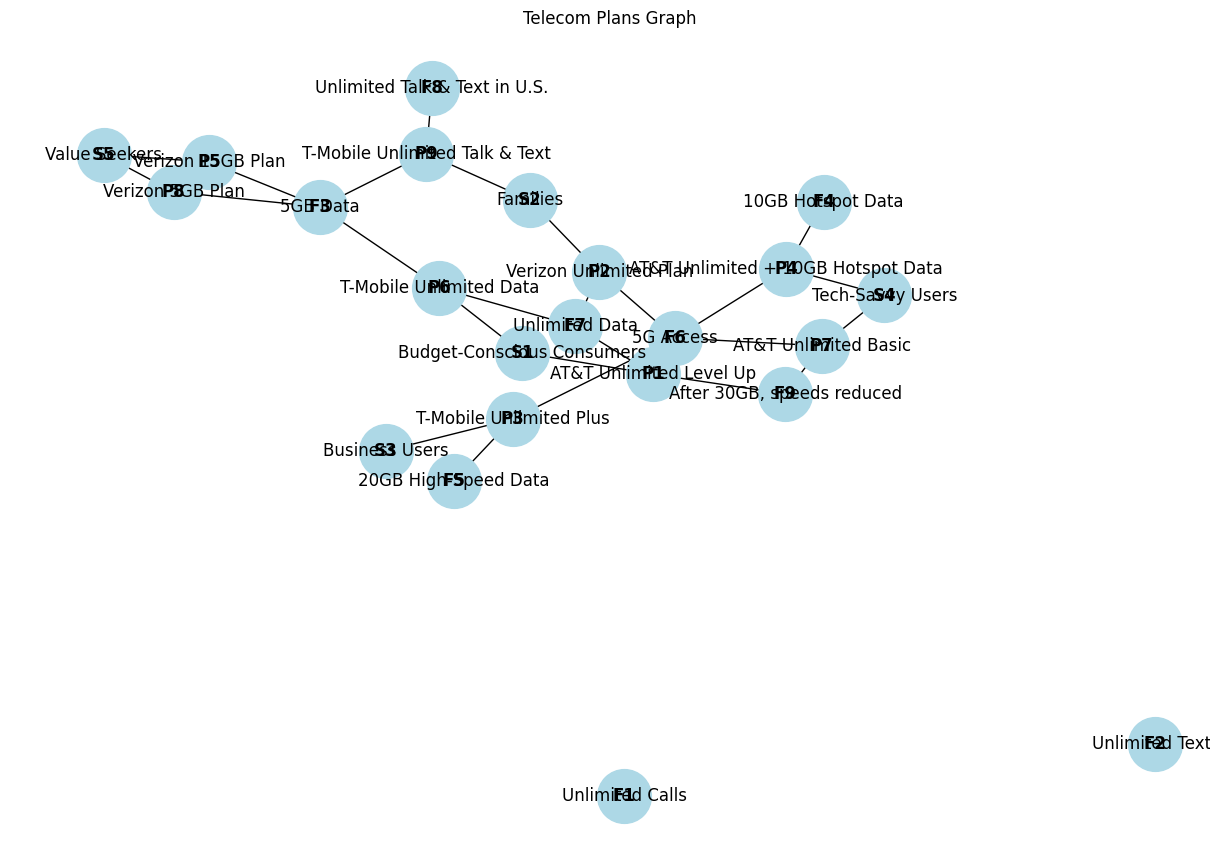

Underserved Segments: ['Budget-Conscious Consumers', 'Families', 'Business Users']


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

def generate_synthetic_data():
    # Plans data for various telecom providers
    plans = [
        {"id": "P1", "name": "AT&T Unlimited Level Up", "details": "Unlimited talk, text & data with 5G access. After 30GB, speeds slowed to 1.5Mbps.", "tags": ["AT&T", "Prepaid"]},
        {"id": "P2", "name": "Verizon Unlimited Plan", "details": "Unlimited talk, text & data with 5G access. After 25GB, speeds may be reduced during congestion.", "tags": ["Verizon", "Prepaid"]},
        {"id": "P3", "name": "T-Mobile Unlimited Plus", "details": "Unlimited data with 20GB at high speeds, then reduced. Includes unlimited talk & text.", "tags": ["T-Mobile", "Prepaid"]},
        {"id": "P4", "name": "AT&T Unlimited + 10GB Hotspot Data", "details": "Unlimited talk, text & data with 5G access. Includes 10GB hotspot data.", "tags": ["AT&T", "Prepaid"]},
        {"id": "P5", "name": "Verizon 15GB Plan", "details": "15GB of high-speed data, then reduced. Unlimited talk & text.", "tags": ["Verizon", "Prepaid"]},
        {"id": "P6", "name": "T-Mobile Unlimited Data", "details": "Unlimited data with 5GB at high speeds, then reduced. Unlimited talk & text.", "tags": ["T-Mobile", "Prepaid"]},
        {"id": "P7", "name": "AT&T Unlimited Basic", "details": "Unlimited talk, text & data with 5G access. After 30GB, speeds slowed to 1.5Mbps.", "tags": ["AT&T", "Prepaid"]},
        {"id": "P8", "name": "Verizon 5GB Plan", "details": "5GB of high-speed data, then reduced. Unlimited talk & text.", "tags": ["Verizon", "Prepaid"]},
        {"id": "P9", "name": "T-Mobile Unlimited Talk & Text", "details": "Unlimited talk & text within the U.S. 5GB of high-speed data, then reduced.", "tags": ["T-Mobile", "Prepaid"]},
    ]

    # Features that these telecom plans provide
    features = [
        {"id": "F1", "name": "Unlimited Calls"},
        {"id": "F2", "name": "Unlimited Texts"},
        {"id": "F3", "name": "5GB Data"},
        {"id": "F4", "name": "10GB Hotspot Data"},
        {"id": "F5", "name": "20GB High-Speed Data"},
        {"id": "F6", "name": "5G Access"},
        {"id": "F7", "name": "Unlimited Data"},
        {"id": "F8", "name": "Unlimited Talk & Text in U.S."},
        {"id": "F9", "name": "After 30GB, speeds reduced"}
    ]

    # Customer segments for targeting these plans
    segments = [
        {"id": "S1", "name": "Budget-Conscious Consumers", "details": "Attracted to prepaid plans with limited data and lower costs."},
        {"id": "S2", "name": "Families", "details": "Seek family plans with shared data and multiple lines at discounted rates."},
        {"id": "S3", "name": "Business Users", "details": "Require plans with higher data allowances, priority customer service, and additional features like mobile hotspot."},
        {"id": "S4", "name": "Tech-Savvy Users", "details": "Interested in the latest devices, high-speed data, and advanced features like 5G access."},
        {"id": "S5", "name": "Value Seekers", "details": "Look for plans that provide great value for money, combining affordable pricing with decent features."},
    ]

    return plans, features, segments


# Generate synthetic data
plans, features, segments = generate_synthetic_data()

# Build the graph
G = nx.Graph()

# Add nodes for plans, features, and segments
for plan in plans:
    G.add_node(plan["id"], label="Plan", name=plan["name"])
for feature in features:
    G.add_node(feature["id"], label="Feature", name=feature["name"])
for segment in segments:
    G.add_node(segment["id"], label="Segment", name=segment["name"])

# Add edges between plans and features
feature_relationships = [
    ("P1", "F6"), ("P1", "F7"), ("P1", "F9"),
    ("P2", "F6"), ("P2", "F7"),
    ("P3", "F6"), ("P3", "F5"),
    ("P4", "F6"), ("P4", "F4"),
    ("P5", "F3"),
    ("P6", "F3"), ("P6", "F7"),
    ("P7", "F6"), ("P7", "F9"),
    ("P8", "F3"),
    ("P9", "F3"), ("P9", "F8"),
]
G.add_edges_from(feature_relationships)

# Add edges between plans and segments
segment_relationships = [
    ("P1", "S1"), ("P2", "S2"),
    ("P3", "S3"), ("P4", "S4"),
    ("P5", "S5"), ("P6", "S1"),
    ("P7", "S4"), ("P8", "S5"),
    ("P9", "S2"),
]
G.add_edges_from(segment_relationships)

# Visualize the graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color="lightblue", font_weight="bold", node_size=1500)
labels = nx.get_node_attributes(G, "name")
nx.draw_networkx_labels(G, pos, labels=labels)
plt.title("Telecom Plans Graph")
plt.show()

# Identify underserved segments using random walk
def identify_underserved_segments(graph, num_walks=10, walk_length=5):
    segment_scores = Counter()
    for _ in range(num_walks):
        for segment in [n for n, d in graph.nodes(data=True) if d["label"] == "Segment"]:
            current = segment
            for _ in range(walk_length):
                neighbors = list(graph.neighbors(current))
                if not neighbors:
                    break
                current = neighbors[0]
                segment_scores[segment] += 1
    underserved_segments = sorted(segment_scores, key=segment_scores.get)[:3]  # Top 3 underserved
    return underserved_segments

underserved_segments = identify_underserved_segments(G)
print(f"Underserved Segments: {[G.nodes[s]['name'] for s in underserved_segments]}")

In [ ]:
def recommend_plans_for_segments(graph, underserved_segments, top_n=3):
    """
    Recommend plans for underserved segments based on graph connectivity.

    Args:
        graph (networkx.Graph): The telecom plans graph.
        underserved_segments (list): List of underserved segment node IDs.
        top_n (int): Number of plans to recommend for each underserved segment.

    Returns:
        dict: A dictionary with segment names as keys and recommended plan names as values.
    """
    recommendations = {}

    for segment in underserved_segments:
        # Get plans connected to the underserved segment
        connected_plans = [neighbor for neighbor in graph.neighbors(segment) if graph.nodes[neighbor]["label"] == "Plan"]

        # Rank plans based on their overall connectivity to features
        plan_scores = {}
        for plan in connected_plans:
            features_connected = [neighbor for neighbor in graph.neighbors(plan) if graph.nodes[neighbor]["label"] == "Feature"]
            plan_scores[plan] = len(features_connected)  # Higher score means more features

        # Sort plans by scores and select top_n
        top_plans = sorted(plan_scores, key=plan_scores.get, reverse=True)[:top_n]
        recommendations[graph.nodes[segment]["name"]] = [graph.nodes[plan]["name"] for plan in top_plans]

    return recommendations


# Generate recommendations for underserved segments
underserved_segment_names = [G.nodes[s]["name"] for s in underserved_segments]
recommendations = recommend_plans_for_segments(G, underserved_segments)

# Display recommendations
print("Recommendations for Underserved Segments:")
for segment, plans in recommendations.items():
    print(f"  - {segment}: {', '.join(plans)}")

Recommendations for Underserved Segments:
  - Budget-Conscious Consumers: AT&T Unlimited Level Up, T-Mobile Unlimited Data
  - Families: Verizon Unlimited Plan, T-Mobile Unlimited Talk & Text
  - Business Users: T-Mobile Unlimited Plus


In [ ]:
from networkx import betweenness_centrality, degree_centrality, clustering

def score_underserved_segments(graph, segments):
    """
    Score underserved segments based on graph metrics.

    Args:
        graph (networkx.Graph): The telecom plans graph.
        segments (list): List of segment node IDs.

    Returns:
        dict: Scores for each segment.
    """
    centrality_scores = betweenness_centrality(graph)
    degree_scores = degree_centrality(graph)
    clustering_scores = clustering(graph)

    segment_scores = {}
    for segment in segments:
        # Combine scores (weights can be adjusted based on use case)
        score = (
            0.5 * centrality_scores[segment] +
            0.3 * degree_scores[segment] +
            0.2 * clustering_scores[segment]
        )
        segment_scores[segment] = score

    # Sort segments by score
    sorted_scores = dict(sorted(segment_scores.items(), key=lambda item: item[1], reverse=True))
    return sorted_scores


def score_recommended_plans(graph, segment, plans):
    """
    Score recommended plans based on graph connectivity and relevance to segment.

    Args:
        graph (networkx.Graph): The telecom plans graph.
        segment (str): Segment node ID.
        plans (list): List of plan node IDs connected to the segment.

    Returns:
        dict: Scores for each recommended plan.
    """
    plan_scores = {}
    for plan in plans:
        # Number of features the plan has
        features_connected = [neighbor for neighbor in graph.neighbors(plan) if graph.nodes[neighbor]["label"] == "Feature"]

        # Weight based on connection to the given segment
        weight = 1 if graph.has_edge(segment, plan) else 0.5

        # Score combines feature richness and relevance to the segment
        plan_scores[plan] = weight * len(features_connected)

    # Sort plans by score
    sorted_scores = dict(sorted(plan_scores.items(), key=lambda item: item[1], reverse=True))
    return sorted_scores


# Rank underserved segments
segment_scores = score_underserved_segments(G, underserved_segments)
print("Underserved Segment Scores:")
for segment, score in segment_scores.items():
    print(f"  - {G.nodes[segment]['name']}: {score:.2f}")

# Rank plans for each underserved segment
print("\nPlan Recommendations with Scores:")
for segment, segment_score in segment_scores.items():
    segment_name = G.nodes[segment]["name"]
    connected_plans = [neighbor for neighbor in G.neighbors(segment) if G.nodes[neighbor]["label"] == "Plan"]

    plan_scores = score_recommended_plans(G, segment, connected_plans)
    print(f"  - {segment_name} (Segment Score: {segment_score:.2f}):")
    for plan, plan_score in plan_scores.items():
        print(f"      * {G.nodes[plan]['name']} (Plan Score: {plan_score:.2f})")

Underserved Segment Scores:
  - Families: 0.09
  - Budget-Conscious Consumers: 0.06
  - Business Users: 0.01

Plan Recommendations with Scores:
  - Families (Segment Score: 0.09):
      * Verizon Unlimited Plan (Plan Score: 2.00)
      * T-Mobile Unlimited Talk & Text (Plan Score: 2.00)
  - Budget-Conscious Consumers (Segment Score: 0.06):
      * AT&T Unlimited Level Up (Plan Score: 3.00)
      * T-Mobile Unlimited Data (Plan Score: 2.00)
  - Business Users (Segment Score: 0.01):
      * T-Mobile Unlimited Plus (Plan Score: 2.00)
